# DS605 - Fundamentals of Machine Learning
## Lab Assignment 4: End-to-End Machine Learning Project
### Airbnb Price Prediction

**Dataset:** New York City Airbnb Open Data (`AB_NYC_2019.csv`)



In [4]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:


df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
# Display first 5 rows

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 1. Dataset Understanding


In [7]:


print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 48895
Number of columns: 16


In [8]:
# Displaying all column names

df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [9]:
# Checking data types and non-null values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [10]:
# Checking missing values

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

In [11]:
# Checking duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
# Basic statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


## 2. Data Quality and Initial Cleaning



In [13]:
# Checking duplicate rows

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [14]:

print("Listings with price = 0:", (df["price"] == 0).sum())
print("\nPrice percentiles:")
print(df["price"].quantile([0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]))

Listings with price = 0: 11

Price percentiles:
0.00        0.0
0.25       69.0
0.50      106.0
0.75      175.0
0.90      269.0
0.95      355.0
0.99      799.0
1.00    10000.0
Name: price, dtype: float64


In [15]:

print(df["minimum_nights"].quantile(
    [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
))

0.00       1.0
0.25       1.0
0.50       3.0
0.75       5.0
0.90      28.0
0.95      30.0
0.99      45.0
1.00    1250.0
Name: minimum_nights, dtype: float64


In [16]:

print("Neighbourhood Groups:")
print(df["neighbourhood_group"].value_counts())

print("\nRoom Types:")
print(df["room_type"].value_counts())

Neighbourhood Groups:
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

Room Types:
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


In [17]:

df.nunique().sort_values()

room_type                             3
neighbourhood_group                   5
calculated_host_listings_count       47
minimum_nights                      109
neighbourhood                       221
availability_365                    366
number_of_reviews                   394
price                               674
reviews_per_month                   937
last_review                        1764
host_name                         11452
longitude                         14718
latitude                          19048
host_id                           37457
name                              47905
id                                48895
dtype: int64

### Cleaning Decisions

After checking the dataset, I made the following changes before using it for machine learning:

1. There were no duplicate rows, so nothing had to be removed for duplication.
2. I found 11 listings with a price of 0. Since a free Airbnb listing is not realistic for this prediction task, I removed those rows.
3. The price column had some very large values. Most listings were below $799, while the maximum price was $10,000. To reduce the effect of these extreme values, I removed listings above the 99th percentile.
4. `minimum_nights` also had some unusually high values, with the maximum reaching 1250 nights. Instead of removing those listings completely, I capped the extreme values at the 99th percentile.
5. Missing values in `reviews_per_month` were replaced with 0 because these listings usually had no reviews.
6. Columns such as `id`, `name`, `host_id`, and `host_name` were removed because they are mainly identifiers or text fields and are not useful for predicting the price of a new listing.
7. `last_review` was also removed because it had many missing values and the date itself was not directly useful for the model in its current form.

In [18]:

df_clean = df.copy()

print("Original number of rows:", df_clean.shape[0])

Original number of rows: 48895


In [19]:

df_clean = df_clean[df_clean["price"] > 0].copy()

print("Rows after removing zero-price listings:", df_clean.shape[0])

Rows after removing zero-price listings: 48884


In [20]:
# Calculate the 99th percentile of price

price_upper_limit = df_clean["price"].quantile(0.99)

print("99th percentile of price:", price_upper_limit)

# Remove listings above the 99th percentile
df_clean = df_clean[df_clean["price"] <= price_upper_limit].copy()

print("Rows after price outlier removal:", df_clean.shape[0])

99th percentile of price: 799.0
Rows after price outlier removal: 48410


In [21]:
# Calculate the 99th percentile of minimum_nights

minimum_nights_limit = df_clean["minimum_nights"].quantile(0.99)

print("99th percentile of minimum_nights:", minimum_nights_limit)

# Cap extreme minimum-night values
df_clean["minimum_nights"] = df_clean["minimum_nights"].clip(
    upper=minimum_nights_limit
)

99th percentile of minimum_nights: 40.0


In [22]:
# Missing reviews_per_month generally indicates that the listing has no reviews

df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

print("Missing reviews_per_month:",
      df_clean["reviews_per_month"].isnull().sum())

Missing reviews_per_month: 0


### Feature Engineering

Two additional features are created:

- `has_reviews`: Indicates whether a listing has received at least one review.
- `is_multi_listing_host`: Indicates whether the host manages more than one Airbnb listing.


In [23]:

df_clean["has_reviews"] = (df_clean["number_of_reviews"] > 0).astype(int)

df_clean["is_multi_listing_host"] = (
    df_clean["calculated_host_listings_count"] > 1
).astype(int)

df_clean[[
    "number_of_reviews",
    "has_reviews",
    "calculated_host_listings_count",
    "is_multi_listing_host"
]].head()

,number_of_reviews,has_reviews,calculated_host_listings_count,is_multi_listing_host
0,9,1,6,1
1,45,1,2,1
2,0,0,1,0
3,270,1,1,0
4,9,1,1,0


In [24]:

columns_to_drop = [
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review"
]

df_clean = df_clean.drop(columns=columns_to_drop)

df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews,is_multi_listing_host
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,1,1
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,1,1
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,0,0
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1,0
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,1,0


In [25]:
#  cleaned dataset

print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nRemaining price range:")
print("Minimum price:", df_clean["price"].min())
print("Maximum price:", df_clean["price"].max())

print("\nColumns used:")
print(df_clean.columns.tolist())

Cleaned dataset shape: (48410, 13)

Missing values:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
has_reviews                       0
is_multi_listing_host             0
dtype: int64

Remaining price range:
Minimum price: 10
Maximum price: 799

Columns used:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_reviews', 'is_multi_listing_host']


### Observation

After cleaning, 48,410 listings remained in the dataset. There are no missing values left in the columns that will be used for modeling. The price range is now between $10 and $799 after removing the extreme price outliers.

Two new features were also created. `has_reviews` shows whether a listing has received any reviews, while `is_multi_listing_host` shows whether the host manages more than one listing. These may help the model capture differences between new and established listings and between individual and multi-property hosts.

## 3. Exploratory Data Analysis


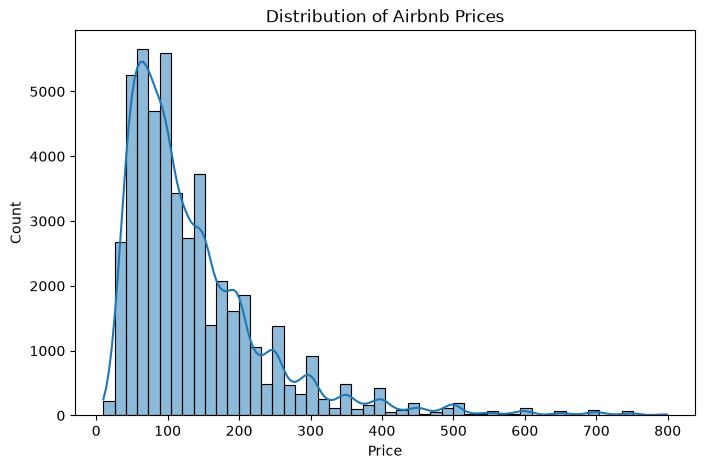

In [26]:
# Price distribution

plt.figure(figsize=(8, 5))
sns.histplot(df_clean["price"], bins=50, kde=True)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

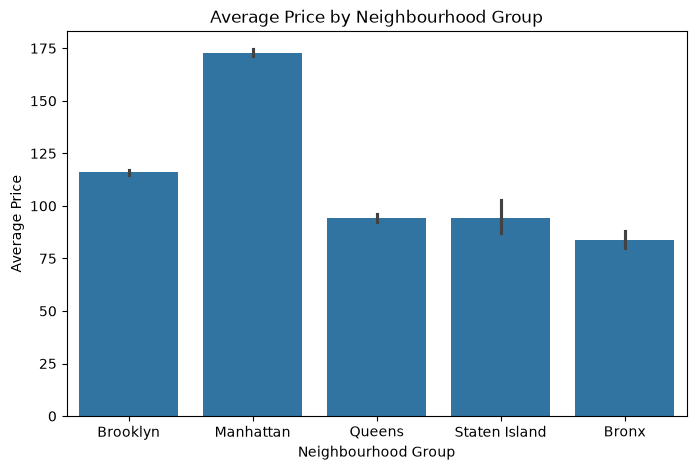

In [27]:
# Average price by neighbourhood group

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="neighbourhood_group",
    y="price"
)

plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")

plt.show()

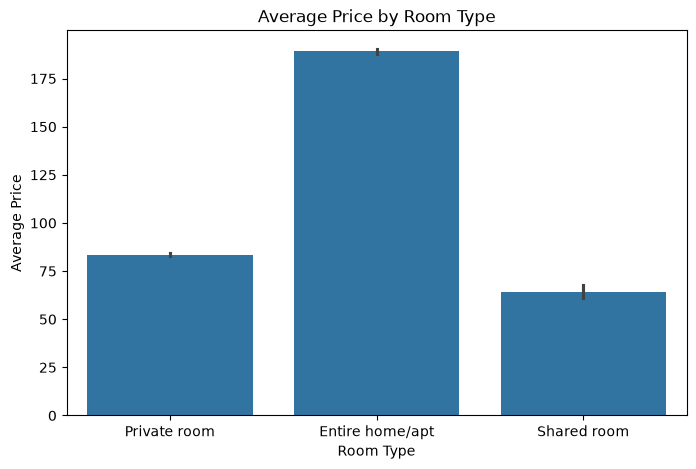

In [29]:
# Average price by room type

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="room_type",
    y="price"
)

plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")

plt.show()

### Observation

- Most Airbnb listings are in the lower and middle price range, while fewer listings are very expensive.
- Manhattan has the highest average price compared with the other neighbourhood groups.
- Entire home/apartment listings are more expensive than private rooms and shared rooms.
- This shows that both location and room type are likely to be important features for price prediction.

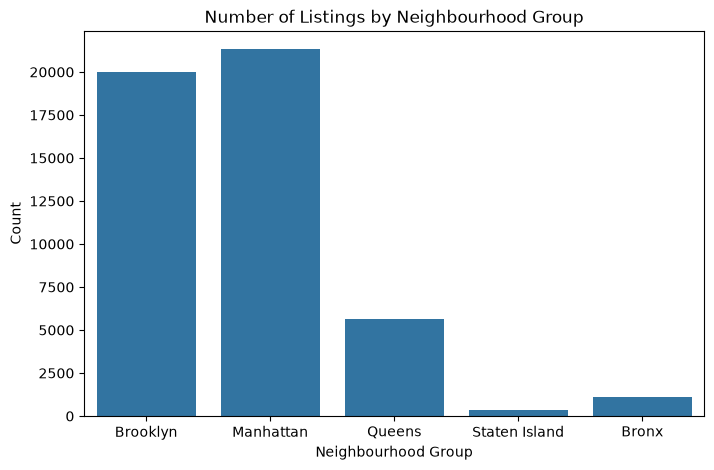

In [30]:
# Number of listings by neighbourhood group

plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="neighbourhood_group")
plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")
plt.show()

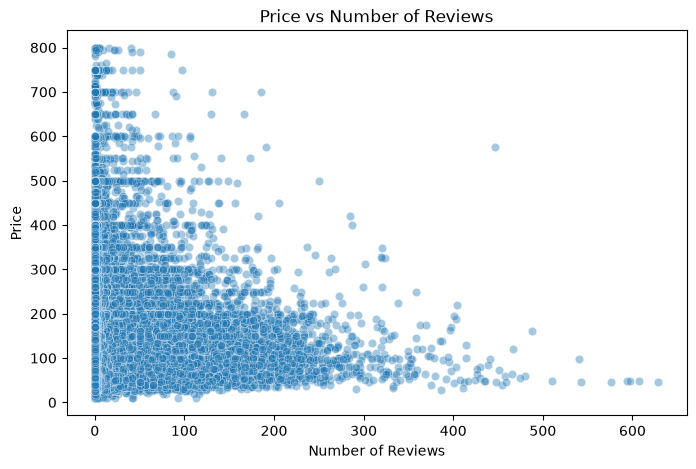

In [31]:
# Price vs number of reviews

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="number_of_reviews",
    y="price",
    alpha=0.4
)

plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()

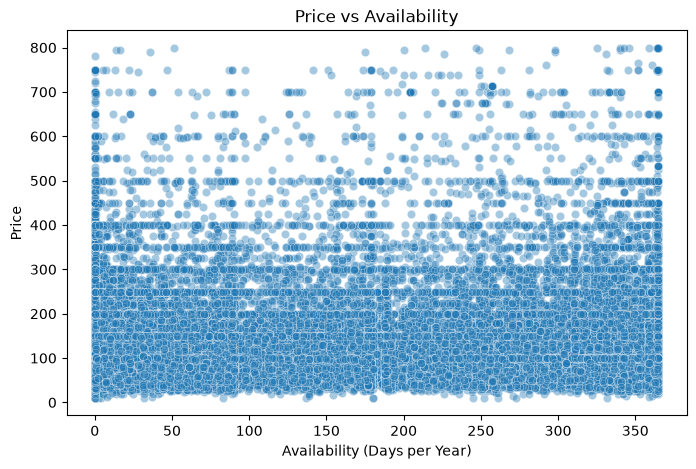

In [32]:
# Price vs availability

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="availability_365",
    y="price",
    alpha=0.4
)

plt.title("Price vs Availability")
plt.xlabel("Availability (Days per Year)")
plt.ylabel("Price")
plt.show()

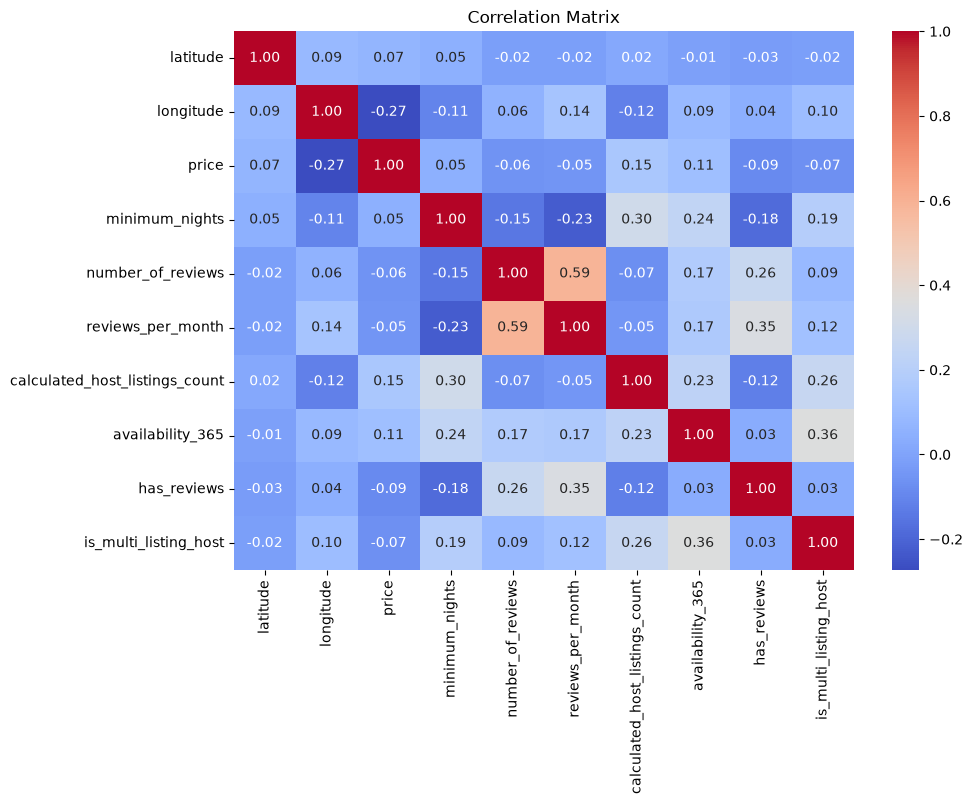

In [33]:
# Correlation matrix

numeric_columns = df_clean.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Observation

- Most listings are in Manhattan and Brooklyn. Queens has much fewer listings, while the Bronx and Staten Island have the least.
- Listings with a very high number of reviews are mostly in the lower price range. Expensive listings usually have fewer reviews.
- Availability does not show a very clear relationship with price. Listings at different price levels are spread across the full range of availability.
- In the correlation matrix, most numerical features have only weak correlation with price.
- Longitude shows a noticeable negative correlation with price, while `calculated_host_listings_count` and `availability_365` have a small positive correlation.
- `number_of_reviews` and `reviews_per_month` are strongly related to each other, which is expected because both represent review activity.

## 4. Data Preprocessing

In [34]:
# Separate input features and target

X = df_clean.drop("price", axis=1)
y = df_clean["price"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (48410, 12)
Target shape: (48410,)


In [35]:

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "has_reviews",
    "is_multi_listing_host"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['neighbourhood_group', 'neighbourhood', 'room_type']
Numerical features: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_reviews', 'is_multi_listing_host']


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (38728, 12)
Testing data: (9682, 12)


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Observation

The dataset is divided into 80% training data and 20% testing data. Categorical features such as neighbourhood and room type will be converted into numerical form using one-hot encoding. Numerical features will be scaled so that features with larger values do not dominate the model.

## 5. Model Training and Evaluation


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [40]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,49.879056,79.067064,0.425506
1,Decision Tree,60.670109,101.451985,0.054165
2,Random Forest,44.919334,72.888091,0.511789


### Observation

Random Forest performed the best among the three models. It gave the lowest MAE and RMSE and the highest R² score. Linear Regression also performed reasonably well, while the Decision Tree gave much weaker results on the test data.

Based on these results, Random Forest is the best model to take forward for further checking and tuning.

## 6. Checking Overfitting and Underfitting


In [41]:
comparison_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    comparison_results.append({
        "Model": name,
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred))
    })

overfit_df = pd.DataFrame(comparison_results)

overfit_df

,Model,Train R2,Test R2,Train RMSE,Test RMSE
0,Linear Regression,0.420648,0.425506,78.887691,79.067064
1,Decision Tree,1.000000,0.054165,0.000000,101.451985
2,Random Forest,0.927808,0.511789,27.847355,72.888091


### Observation

The Decision Tree is clearly overfitting because it performs perfectly on the training data but performs poorly on the testing data.

Random Forest also shows some overfitting because its training R² is much higher than its testing R². However, it still gives the best performance on unseen data.

Linear Regression has very similar training and testing scores, so it is not overfitting, but its overall performance is lower than Random Forest.

Because Random Forest gives the best test results, I will tune its parameters to try to reduce overfitting and improve its performance.

## 7. Hyperparameter Tuning


In [42]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

In [43]:
param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, 1.0]
}

In [45]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 0.7, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best e

In [46]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 0.7, 'model__max_depth': 15}


In [47]:
best_model = random_search.best_estimator_

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

print("Train RMSE:",
      np.sqrt(mean_squared_error(y_train, train_pred)))

print("Test RMSE:",
      np.sqrt(mean_squared_error(y_test, test_pred)))

print("Test MAE:",
      mean_absolute_error(y_test, test_pred))

Train R2: 0.6790501082905176
Test R2: 0.5272547921287243
Train RMSE: 58.71603284331219
Test RMSE: 71.72432805000547
Test MAE: 43.80946431648757


In [48]:
best_model = random_search.best_estimator_

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

print("Train RMSE:",
      np.sqrt(mean_squared_error(y_train, train_pred)))

print("Test RMSE:",
      np.sqrt(mean_squared_error(y_test, test_pred)))

print("Test MAE:",
      mean_absolute_error(y_test, test_pred))

Train R2: 0.6790501082905176
Test R2: 0.5272547921287243
Train RMSE: 58.71603284331219
Test RMSE: 71.72432805000547
Test MAE: 43.80946431648757


### Observation

After hyperparameter tuning, the Random Forest became less overfitted. The gap between training and testing performance reduced compared with the original model.

The test R² improved from about 0.51 to 0.53, while both RMSE and MAE also improved slightly. Because of this, the tuned Random Forest is selected as the final model.

## 8.  Final Model


In [49]:
import joblib

joblib.dump(best_model, "airbnb_price_pipeline.pkl")

print("Final model saved successfully.")

Final model saved successfully.
